In [35]:
#import the pandas library function in pd
import pandas as pd

In [36]:
#Use the pandas library funtion read the csv data file and store it in the dataset variable
dataset=pd.read_csv("insurance_pre.csv")

In [37]:
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [38]:
#Using the get_dummies function, we convert a categorical (nominal) column like “sex & smoker” into multiple separate columns. This process is called one-hot encoding.
# True=1 and false=0
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [39]:
# show the column name
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [40]:
#input - In the dataset column value and store it the independent variable. Only input heading value put here
independent=dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [41]:
#output - In the dataset column value and store it the dependent variable. Only output heading value put here
dependent=dataset[["charges"]]
dependent

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [42]:
#Split training and test set using sklearn library and import only train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [43]:
x_train

,age,bmi,children,sex_male,smoker_yes
1163,18,28.215,0,0,0
196,39,32.800,0,0,0
438,52,46.750,5,0,0
183,44,26.410,0,0,0
1298,33,27.455,2,1,0
...,...,...,...,...,...
763,27,26.030,0,1,0
835,42,35.970,2,1,0
1216,40,25.080,0,1,0
559,19,35.530,0,1,0


In [159]:
#using sklearn library and import decision tree regressor
from sklearn.tree import DecisionTreeRegressor
#regressor=DecisionTreeRegressor()
# Below the add paramter changes in criterion, max features & splitter
regressor=DecisionTreeRegressor(criterion='poisson',max_features='log2',splitter='random')
regressor=regressor.fit(x_train,y_train) # This code will create model

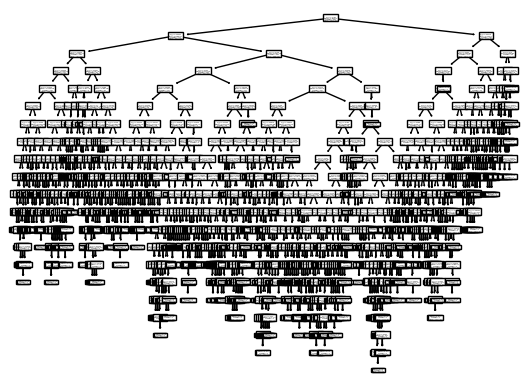

In [160]:
import matplotlib.pyplot as plt # import matplotlib library function in plt
from sklearn import tree # using sklearn library to import the tree function
tree.plot_tree(regressor)
plt.show()

In [161]:
#Evaluation metrics - process of prediction
y_pred=regressor.predict(x_test)

In [162]:
#Calculate the r_Score value and weather check the model is good or bad.
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [163]:
#Print the r_score value
r_score

0.6443704047748846